In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

import plotnine as p9

import liana as li
import decoupler as dc
import omnipath as op

# Import DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [2]:
adata = sc.read_h5ad('/cluster/pixstor/warrenwc-lab/users/evan/SingleCell/Total_lung/total_lung_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 37608 × 2706
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts', 'leiden', 'cell type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell type_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'population_colors', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
adata_raw = sc.read_h5ad('/cluster/pixstor/warrenwc-lab/users/rachel/single-cell/251217-chickenRBCs/3-cluster/raw_counts.h5ad')
adata_raw

AnnData object with n_obs × n_vars = 37608 × 15590
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts'
    var: 'n_cells'
    uns: 'sample_id_colors'

In [4]:
adata_raw = adata_raw[adata.obs.index]
adata_raw.obs["cell type"] = adata.obs["cell type"]
adata_raw

/tmp/ipykernel_1814098/676745017.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


AnnData object with n_obs × n_vars = 37608 × 15590
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts', 'cell type'
    var: 'n_cells'
    uns: 'sample_id_colors'

In [5]:
deg = pd.read_csv("Liana/dea_results.csv", index_col = 0)
pseudobulk = deg[deg["pvalue"] <= 0.05]
pseudobulk

,cell type,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
index,,,,,,,
CYFIP1,Epithelial,254.279196,-0.939557,0.337112,-3.238344,1.202259e-03,1.320221e-02
PIM3,Epithelial,78.489456,1.999396,0.329823,6.382581,1.741276e-10,1.368322e-08
IL17REL,Epithelial,117.863542,2.241194,0.307812,7.552615,4.266035e-14,7.054876e-12
SLC22A15,Epithelial,14.069656,2.872108,0.747687,4.323305,1.537087e-05,3.339397e-04
NIPA2,Epithelial,31.608118,-0.757571,0.529536,-2.040522,4.129836e-02,1.947174e-01
...,...,...,...,...,...,...,...
ENSGALG00000054070,Vascular,19.137437,1.790177,0.473626,4.262475,2.021753e-05,3.270087e-04
ENSGALG00000034527,Vascular,6.030439,0.905443,0.785059,2.101596,3.558867e-02,1.293107e-01
ENSGALG00000042449,Vascular,5.147003,2.543124,1.061220,3.219575,1.283810e-03,1.034667e-02


In [6]:
celltype_counts = pseudobulk.groupby("cell type").size().reset_index(name="n_genes")
print(celltype_counts)

      cell type  n_genes
0    Epithelial     2488
1  Erythrocytes     5875
2   Fibroblasts     4184
3    Leukocytes     3665
4       T-cells     1981
5  Thrombocytes      271
6      Vascular     3534


In [7]:
#check for NaN values
len(pseudobulk[pseudobulk.isna().any(axis=1)])

0

FORMAT IPA TABLE

In [8]:
filt_pseud = pseudobulk.reset_index().rename(columns={'index': 'gene_symbol'})

In [9]:
filt_pseud = filt_pseud[['gene_symbol', 'log2FoldChange', 'padj', 'cell type']]
filt_pseud

,gene_symbol,log2FoldChange,padj,cell type
0,CYFIP1,-0.939557,1.320221e-02,Epithelial
1,PIM3,1.999396,1.368322e-08,Epithelial
2,IL17REL,2.241194,7.054876e-12,Epithelial
3,SLC22A15,2.872108,3.339397e-04,Epithelial
4,NIPA2,-0.757571,1.947174e-01,Epithelial
...,...,...,...,...
21993,ENSGALG00000054070,1.790177,3.270087e-04,Vascular
21994,ENSGALG00000034527,0.905443,1.293107e-01,Vascular
21995,ENSGALG00000042449,2.543124,1.034667e-02,Vascular
21996,RPS19,-0.283608,1.084076e-01,Vascular


ADD THE BACKGROUND GENES

In [10]:
background_genes  = adata.raw.var_names.tolist()
background_genes

['HMOX1',
 'CYFIP1',
 'PIM3',
 'MAB21L3',
 'MPHOSPH8',
 'IL17REL',
 'SLC22A15',
 'ENSGALG00000052027',
 'TOM1',
 'NIPA2',
 'MLC1',
 'PARP4',
 'NIPA1',
 'ENSGALG00000044768',
 'ENSGALG00000052369',
 'LARGE1',
 'CENPJ',
 'CASQ2',
 'HERC2',
 'ENSGALG00000045414',
 'SYN3',
 'ENSGALG00000055067',
 'FDX1',
 'TIMP3',
 'RDX',
 'VANGL1',
 'CHD1L',
 'FBXO7',
 'ENSGALG00000015059',
 'ZC3H12C',
 'C11orf87',
 'BPIFC',
 'DDX10',
 'TMEM39A',
 'RTCB',
 'B4GALT4',
 'ENSGALG00000022891',
 'PRDM4',
 'POGLUT3',
 'PWP1',
 'MOV10L1',
 'B3GAT1L',
 'ATM',
 'ENSGALG00000015077',
 'PANX2',
 'UPK1B',
 'TRABD',
 'BTBD11',
 'OCA2',
 'CRY1',
 'ACAT1',
 'ENSGALG00000019240',
 'GABRG3',
 'CUL5',
 'IGSF11',
 'GABRA5',
 'SELENOO',
 'TUBGCP6',
 'RAB39A',
 'SLC35F2',
 'GABRB3',
 'ENSGALG00000051879',
 'LSAMP',
 'MTERF2',
 'SLN',
 'TMEM263',
 'ATP10A',
 'ELMOD1',
 'ENSGALG00000051829',
 'RIC8B',
 'UBE3A',
 'ENSGALG00000051043',
 'RFX4',
 'HDAC10',
 'CNGA3',
 'POLR3B',
 'MAPK12',
 'ALKBH8',
 'ENSGALG00000040709',
 'MAPK11'

In [11]:
back_df_all = pd.DataFrame({"gene_symbol": background_genes})
back_df_all

,gene_symbol
0,HMOX1
1,CYFIP1
2,PIM3
3,MAB21L3
4,MPHOSPH8
...,...
15585,ENSGALG00000053779
15586,ENSGALG00000052217
15587,ENSGALG00000052401
15588,ENSGALG00000052141


In [12]:
# Save full background gene list
back_df_all.to_csv("Liana/background_all.tsv", sep='\t', index=False, header=False)

In [13]:
# Add dummy values required for IPA
back_df_all["log2FoldChange"] = 0
back_df_all["padj"] = 1
back_df_all["cell type"] = "background"

In [14]:
# Find overlapping genes BEFORE filtering them out
removed_genes = back_df_all[back_df_all["gene_symbol"].isin(filt_pseud["gene_symbol"])].copy()

print("Number of genes removed from background:", len(removed_genes))
display(removed_genes)

Number of genes removed from background: 10546


,gene_symbol,log2FoldChange,padj,cell type
0,HMOX1,0,1,background
1,CYFIP1,0,1,background
2,PIM3,0,1,background
4,MPHOSPH8,0,1,background
5,IL17REL,0,1,background
...,...,...,...,...
15563,ENSGALG00000054106,0,1,background
15568,ENSGALG00000051372,0,1,background
15570,ENSGALG00000047462,0,1,background
15572,ENSGALG00000049695,0,1,background


In [15]:
# Now perform the filtering
back_df_all = back_df_all[~back_df_all["gene_symbol"].isin(filt_pseud["gene_symbol"])]

In [16]:
# Merge DEGs + background
ipa_input = pd.concat([filt_pseud, back_df_all], ignore_index=True)

In [17]:
# Save final IPA input file
ipa_input.to_csv("Liana/IPA_liana-Lung.csv", index=False)
ipa_input

,gene_symbol,log2FoldChange,padj,cell type
0,CYFIP1,-0.939557,1.320221e-02,Epithelial
1,PIM3,1.999396,1.368322e-08,Epithelial
2,IL17REL,2.241194,7.054876e-12,Epithelial
3,SLC22A15,2.872108,3.339397e-04,Epithelial
4,NIPA2,-0.757571,1.947174e-01,Epithelial
...,...,...,...,...
27037,ENSGALG00000053779,0.000000,1.000000e+00,background
27038,ENSGALG00000052217,0.000000,1.000000e+00,background
27039,ENSGALG00000052401,0.000000,1.000000e+00,background
27040,ENSGALG00000052141,0.000000,1.000000e+00,background


In [18]:
# Count unique genes per cluster
unique_counts = ipa_input.groupby("cell type")["gene_symbol"].nunique()
unique_counts

cell type
Epithelial      2488
Erythrocytes    5875
Fibroblasts     4184
Leukocytes      3665
T-cells         1981
Thrombocytes     271
Vascular        3534
background      5044
Name: gene_symbol, dtype: int64

In [19]:
### GLOBAL DEG PER CLUSTER

import os


os.makedirs("Liana/cluster_csvs", exist_ok=True)

for cluster, df_deg in filt_pseud.groupby("cell type"):

    print(f"Processing cluster: {cluster}")

    # Copy DEGs for safety
    df_deg = df_deg.copy()

    # Add a column so background matches
    back_cluster = back_df_all.copy()
    back_cluster["cell type"] = cluster

    # Merge DEGs + background
    combined = pd.concat([df_deg, back_cluster], ignore_index=True)

    # Remove duplicates BUT prioritize DEGs
    combined = combined.sort_values(
        by=["log2FoldChange"],
        ascending=False,  # DEGs (non-zero) appear before background (zero)
    )

    combined = combined.drop_duplicates(
        subset="gene_symbol",
        keep="first"
    )

    # Save cluster-specific CSV
    out_path = f"Liana/cluster_csvs/IPA_liana-lung_cluster{cluster}.csv"
    combined.to_csv(out_path, index=False)

    print(f"Saved: {out_path} — {len(combined)} genes")


print("All clusters exported with full background included.")


Processing cluster: Epithelial
Saved: Liana/cluster_csvs/IPA_liana-lung_clusterEpithelial.csv — 7532 genes
Processing cluster: Erythrocytes
Saved: Liana/cluster_csvs/IPA_liana-lung_clusterErythrocytes.csv — 10919 genes
Processing cluster: Fibroblasts
Saved: Liana/cluster_csvs/IPA_liana-lung_clusterFibroblasts.csv — 9228 genes
Processing cluster: Leukocytes
Saved: Liana/cluster_csvs/IPA_liana-lung_clusterLeukocytes.csv — 8709 genes
Processing cluster: T-cells
Saved: Liana/cluster_csvs/IPA_liana-lung_clusterT-cells.csv — 7025 genes
Processing cluster: Thrombocytes
Saved: Liana/cluster_csvs/IPA_liana-lung_clusterThrombocytes.csv — 5315 genes
Processing cluster: Vascular
Saved: Liana/cluster_csvs/IPA_liana-lung_clusterVascular.csv — 8578 genes
All clusters exported with full background included.


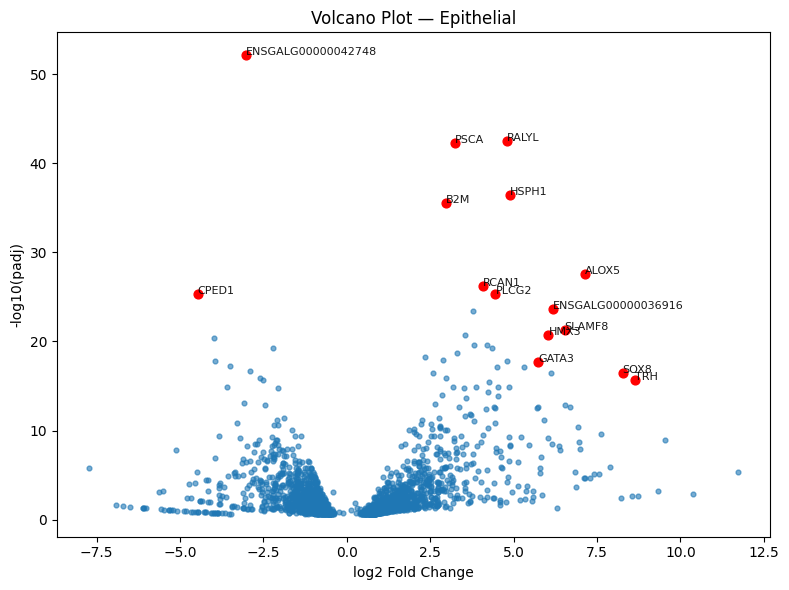

Displayed + saved volcano: volcano_plots/volcano_Epithelial.png


/home/emvrn/.local/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


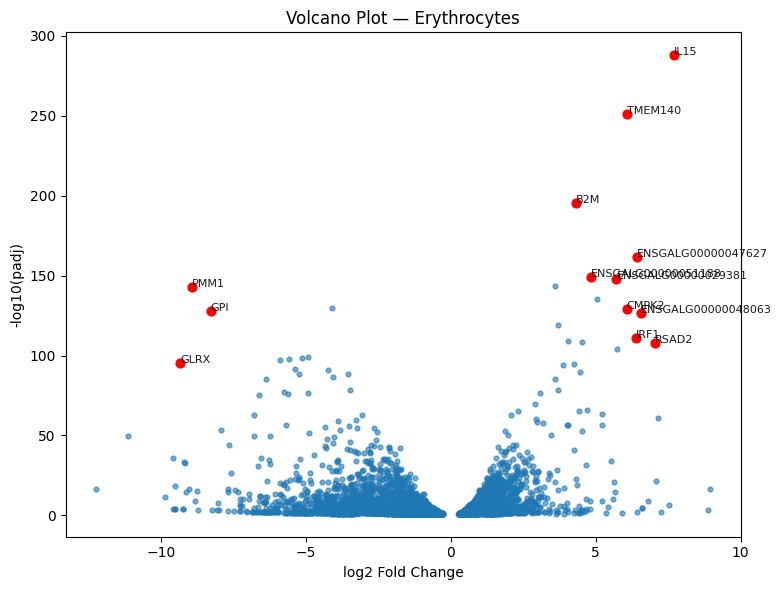

Displayed + saved volcano: volcano_plots/volcano_Erythrocytes.png


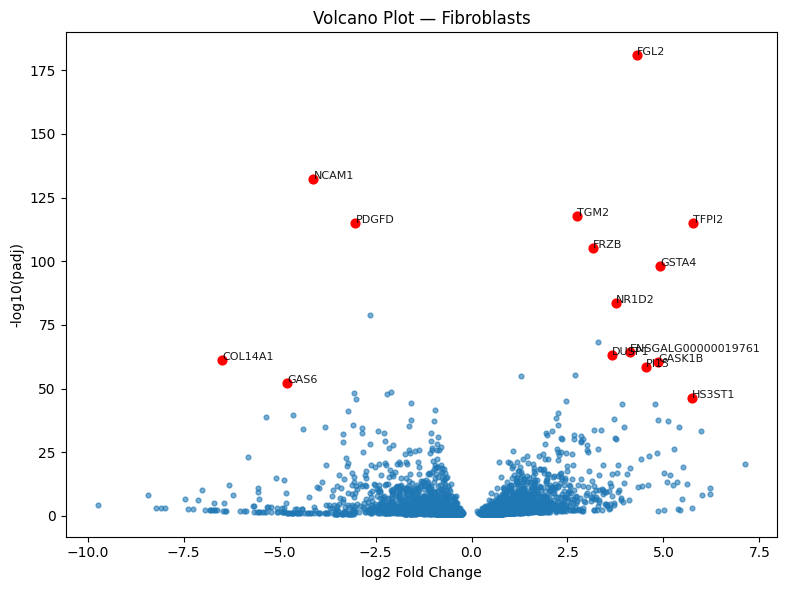

Displayed + saved volcano: volcano_plots/volcano_Fibroblasts.png


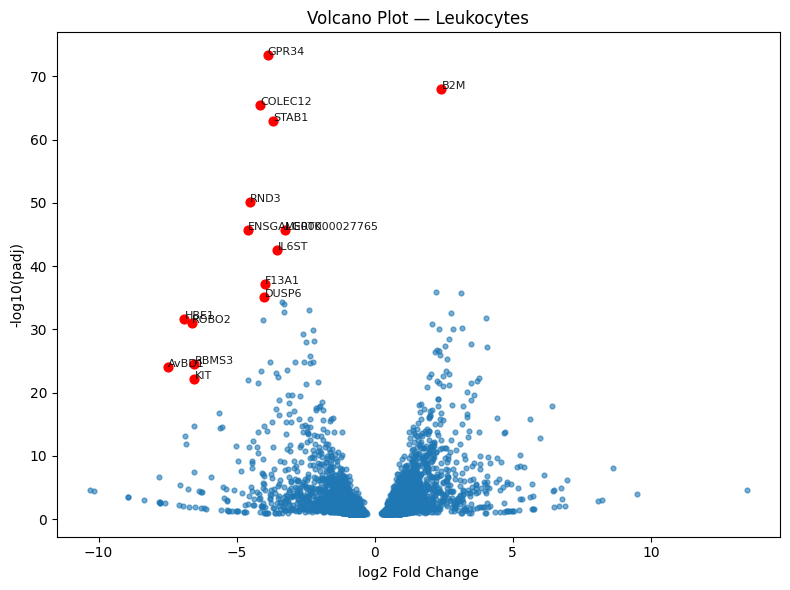

Displayed + saved volcano: volcano_plots/volcano_Leukocytes.png


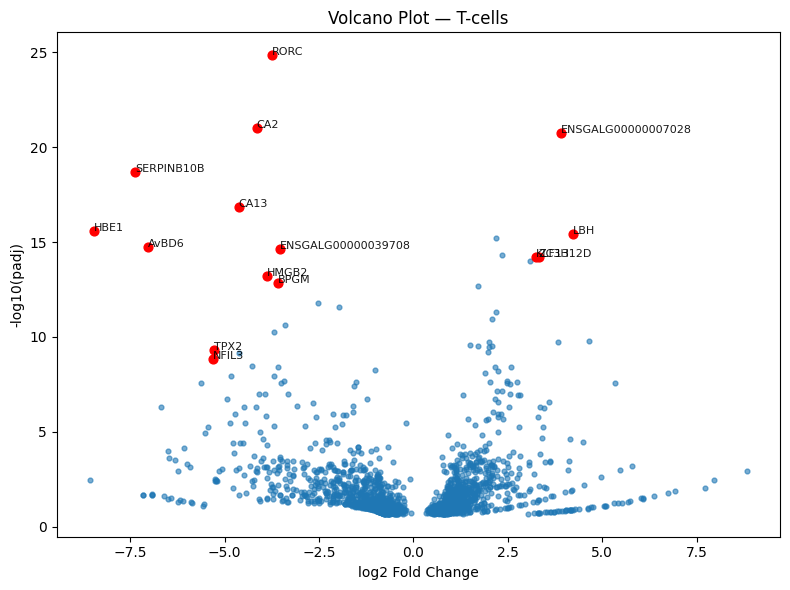

Displayed + saved volcano: volcano_plots/volcano_T-cells.png


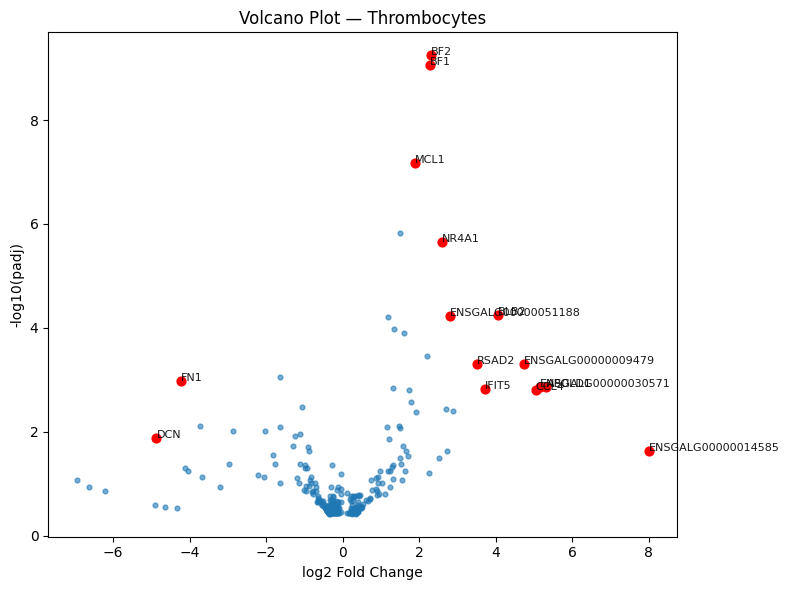

Displayed + saved volcano: volcano_plots/volcano_Thrombocytes.png


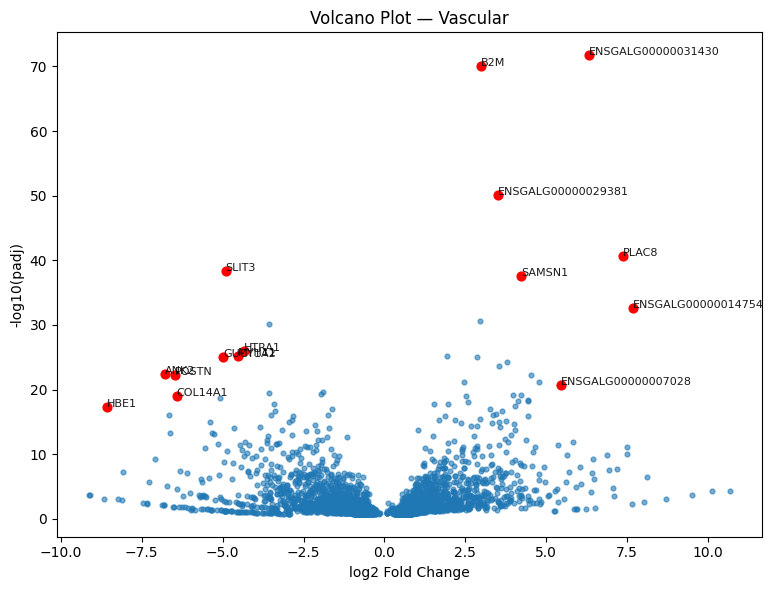

Displayed + saved volcano: volcano_plots/volcano_Vascular.png


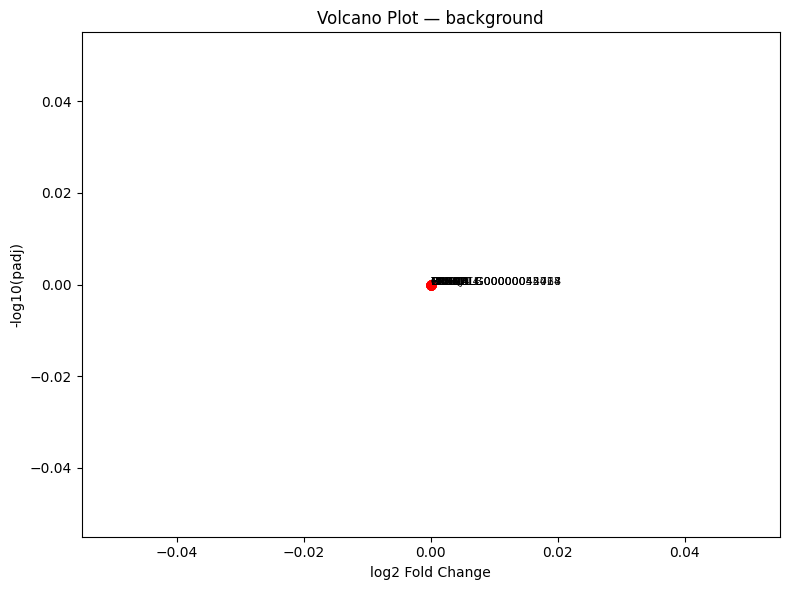

Displayed + saved volcano: volcano_plots/volcano_background.png


In [20]:
import matplotlib.pyplot as plt

# Make output directory
os.makedirs("volcano_plots", exist_ok=True)

TOP_N = 15  # number of top genes to label

# Loop through each cluster and its subset
for cluster, df_cluster in ipa_input.groupby("cell type"):

    df_cluster = df_cluster.copy()
    df_cluster["neglog10_padj"] = -np.log10(df_cluster["padj"])

    # ranking metric: significance × effect size
    df_cluster["rank_score"] = (
        df_cluster["neglog10_padj"] * df_cluster["log2FoldChange"].abs()
    )

    # pick top genes
    top_genes = df_cluster.nlargest(TOP_N, "rank_score")

    # ------------------ Plot ------------------
    plt.figure(figsize=(8, 6))

    # all points
    plt.scatter(
        df_cluster["log2FoldChange"],
        df_cluster["neglog10_padj"],
        alpha=0.6,
        s=12,
    )

    # top highlighted points
    plt.scatter(
        top_genes["log2FoldChange"],
        top_genes["neglog10_padj"],
        s=40,
        color="red"
    )

    # label top genes
    for _, row in top_genes.iterrows():
        plt.text(
            row["log2FoldChange"],
            row["neglog10_padj"],
            row["gene_symbol"],
            fontsize=8,
            alpha=0.9,
        )

    plt.title(f"Volcano Plot — {cluster}")
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(padj)")
    plt.tight_layout()

    # Save file
    fname = f"volcano_plots/volcano_{cluster.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=300)
    plt.show()

    print(f"Displayed + saved volcano: {fname}")

In [21]:
dea = deg[deg["pvalue"] <= 0.05]
dea

,cell type,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
index,,,,,,,
CYFIP1,Epithelial,254.279196,-0.939557,0.337112,-3.238344,1.202259e-03,1.320221e-02
PIM3,Epithelial,78.489456,1.999396,0.329823,6.382581,1.741276e-10,1.368322e-08
IL17REL,Epithelial,117.863542,2.241194,0.307812,7.552615,4.266035e-14,7.054876e-12
SLC22A15,Epithelial,14.069656,2.872108,0.747687,4.323305,1.537087e-05,3.339397e-04
NIPA2,Epithelial,31.608118,-0.757571,0.529536,-2.040522,4.129836e-02,1.947174e-01
...,...,...,...,...,...,...,...
ENSGALG00000054070,Vascular,19.137437,1.790177,0.473626,4.262475,2.021753e-05,3.270087e-04
ENSGALG00000034527,Vascular,6.030439,0.905443,0.785059,2.101596,3.558867e-02,1.293107e-01
ENSGALG00000042449,Vascular,5.147003,2.543124,1.061220,3.219575,1.283810e-03,1.034667e-02


In [23]:
celltype_counts = dea.groupby("cell type").size().reset_index(name="n_genes")
print(celltype_counts)

      cell type  n_genes
0    Epithelial     2488
1  Erythrocytes     5875
2   Fibroblasts     4184
3    Leukocytes     3665
4       T-cells     1981
5  Thrombocytes      271
6      Vascular     3534


In [24]:
#check for NaN values
len(dea[dea.isna().any(axis=1)])

0

In [26]:
# IPA READY DEG table

filt_pseud = (
    dea.reset_index()
       .rename(columns={"index": "gene_symbol"})
       [["gene_symbol", "log2FoldChange", "padj", "cell type"]]
)

print("Total DEGs loaded:", len(filt_pseud))# Clean DEG table
# ------------------------------------------------------
filt_pseud = (
    dea.reset_index()
       .rename(columns={"index": "gene_symbol"})
       [["gene_symbol", "log2FoldChange", "padj", "cell type"]]
)

print("Total DEGs loaded:", len(filt_pseud))

Total DEGs loaded: 21998
Total DEGs loaded: 21998


In [27]:
# Make sure adata_raw and adata have matching cells
adata_raw = adata_raw[adata.obs.index]

# Copy cell-type annotations into BOTH objects
adata.obs["cell type"] = adata.obs["cell type"].astype(str)
adata_raw.obs["cell type"] = adata.obs["cell type"].astype(str)

# Build cluster-specific background gene lists
cluster_background = {}

for cluster in adata_raw.obs["cell type"].unique():

    subset = adata_raw[adata_raw.obs["cell type"] == cluster]

    expressed = (np.array(subset.X.sum(axis=0)).ravel() > 0)
    bg_genes = subset.var_names[expressed].tolist()

    cluster_background[cluster] = bg_genes
    print(f"Cluster {cluster}: {len(bg_genes)} expressed background genes")

Cluster Erythrocytes: 14142 expressed background genes
Cluster Thrombocytes: 11654 expressed background genes
Cluster Vascular: 14476 expressed background genes
Cluster T-cells: 12309 expressed background genes
Cluster Leukocytes: 13757 expressed background genes
Cluster Fibroblasts: 14610 expressed background genes
Cluster Epithelial: 14341 expressed background genes


/tmp/ipykernel_1814098/3100272415.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [28]:
# Create IPA files per cluster = DEGs + background
# ------------------------------------------------------
os.makedirs("cluster_csvs", exist_ok=True)

for cluster in filt_pseud["cell type"].unique():

    # 1. DEGs for this cluster
    degs = filt_pseud[filt_pseud["cell type"] == cluster].copy()

    # 2. Background genes expressed in that cluster
    bg = cluster_background[cluster]

    bg_df = pd.DataFrame({
        "gene_symbol": bg,
        "log2FoldChange": 0,
        "padj": 1,
        "cell type": cluster
    })

    # 3. Remove DEGs from background
    bg_df = bg_df[~bg_df["gene_symbol"].isin(degs["gene_symbol"])]

    # 4. Combine into final IPA table
    ipa_cluster = pd.concat([degs, bg_df], ignore_index=True)

    # 5. Save
    out_file = f"IPAready/IPA_cluster_{cluster}.csv"
    ipa_cluster.to_csv(out_file, index=False)

    print(
        f"Saved {out_file} | "
        f"DEGs: {len(degs)} | "
        f"Background: {len(bg_df)} | "
        f"Total: {len(ipa_cluster)}"
    )

print("DONE.")

Saved IPAready/IPA_cluster_Epithelial.csv | DEGs: 2488 | Background: 11853 | Total: 14341
Saved IPAready/IPA_cluster_Erythrocytes.csv | DEGs: 5875 | Background: 8267 | Total: 14142
Saved IPAready/IPA_cluster_Fibroblasts.csv | DEGs: 4184 | Background: 10426 | Total: 14610
Saved IPAready/IPA_cluster_Leukocytes.csv | DEGs: 3665 | Background: 10092 | Total: 13757
Saved IPAready/IPA_cluster_T-cells.csv | DEGs: 1981 | Background: 10328 | Total: 12309
Saved IPAready/IPA_cluster_Thrombocytes.csv | DEGs: 271 | Background: 11383 | Total: 11654
Saved IPAready/IPA_cluster_Vascular.csv | DEGs: 3534 | Background: 10942 | Total: 14476
DONE.
